In [17]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from voluntary_fixation.envs import SUBJECT_IDS
%matplotlib inline
import warnings
warnings.simplefilter('ignore', FutureWarning)
from scipy.stats import ttest_rel
from voluntary_fixation.dataset.bold_dataset import get_non_overlap_indices_for_concatenate_data
import matplotlib as mpl
from voluntary_fixation.envs import TR, RUN_IDS, SUBJECT_IDS, SAVE_ROOT, NUM_ROIS, BRIGHTNESS_DIR, RUN_VOLUMES, MOVIE_FPS, MOVIE_WIDTH, MOVIE_HEIGHT, EYEMOVE_ROOT
from voluntary_fixation.dataset.bold_dataset import get_non_overlap_indices_for_concatenate_data
from voluntary_fixation.bold2visualfeat.eval_utils import get_label, get_pred_and_gt
from voluntary_fixation.dataset.utils import delayed_label
from himalaya.scoring import correlation_score


mpl.rcParams['pdf.fonttype'] = 42  # TrueTypeフォントを埋め込む
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = ['Arial','DejaVu Sans']
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.unicode_minus'] = False  # マイナス符号の化け防止

# plt.rcParams['font.family'] = 'Times New Roman' # font familyの設定
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 25 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 20 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 20 # 軸だけ変更されます

In [4]:
delay_list = [-3,-2,-1,0,1,2,3,4,5]
pca_components = 2
rois = list(range(44))
sampling_mode = 'segment' # ['session', 'segment', 'sandwitch']
remove_empty_eyetrack = True
csv_dir = os.path.join('../../', SAVE_ROOT, 'bold2feat_strict_ree2/delay{delay}-fo0-mo0')

In [5]:
def get_no_empty_eyetrack_indices(eye_tracking_exist_flag_dir, delay):
    non_overlap_train_indices, non_overlap_test_indices = get_non_overlap_indices_for_concatenate_data(sampling_mode,
                                                                                                       jupyter=True)

    eye_tracking_exist_flags = []
    for run_id in RUN_IDS:
        eye_tracking_exist_flag_path = os.path.join(eye_tracking_exist_flag_dir, f'fg_b_{run_id}-flag.npy')
        eye_tracking_exist_flags.append(np.load(eye_tracking_exist_flag_path))
        assert len(eye_tracking_exist_flags[-1]) == RUN_VOLUMES[run_id-1], 'eye_tracking_exist_flag:{} vs RUN_VOLUMES:{}'.format(len(eye_tracking_exist_flags[-1]), RUN_VOLUMES[run_id-1])
    eye_tracking_exist_flags = np.concatenate(eye_tracking_exist_flags, axis=0) # n_samples of bool
    if delay > 0:
        non_overlap_train_indices = non_overlap_train_indices[:-delay]
        non_overlap_test_indices = non_overlap_test_indices[:-delay]
    elif delay < 0:
        non_overlap_train_indices = non_overlap_train_indices[-delay:]
        non_overlap_test_indices = non_overlap_test_indices[-delay:]
    non_overlap_train_indices_delay = np.array([i for i in non_overlap_train_indices if eye_tracking_exist_flags[i+delay]])
    non_overlap_test_indices_delay  = np.array([i for i in non_overlap_test_indices if eye_tracking_exist_flags[i+delay]])

    non_overlap_train_indices = list(non_overlap_train_indices)
    non_overlap_test_indices = list(non_overlap_test_indices)
    ree_indices_train = [non_overlap_train_indices.index(i) for i in non_overlap_train_indices_delay]
    ree_indices_test = [non_overlap_test_indices.index(i) for i in non_overlap_test_indices_delay]
    return ree_indices_train, ree_indices_test

../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/01-FIXA_PURS_q0.9-sal_q0.9.csv is already exist
sbj01  th2:  0.31246855875
sbj01 zero: 210
sbj01 saliency_th_upper_train:  1057.7329848865415
sbj01 saliency_th_lower_train:  424.8501357814248
label1:: gaze shift with saliency shift and small iou
	 TRAIN:: 398. TEST:: 135
label2:: gaze shift without saliency shift and small iou
	 TRAIN:: 250. TEST:: 91
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/02-FIXA_PURS_q0.9-sal_q0.9.csv is already exist
sbj02  th2:  0.31246855875
sbj02 zero: 28
sbj02 saliency_th_upper_train:  1057.7329848865415
sbj02 saliency_th_lower_train:  424.8501357814248
label1:: gaze shift with saliency shift and small iou
	 TRAIN:: 463. TEST:: 149
label2:: gaze shift without saliency shift and small iou
	 TRAIN:: 321. TEST:: 104
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/03-FIXA_PURS_q0.9-sal_q0.9.csv is already exist
sbj03  th2:  0.31246855875
sbj03 z

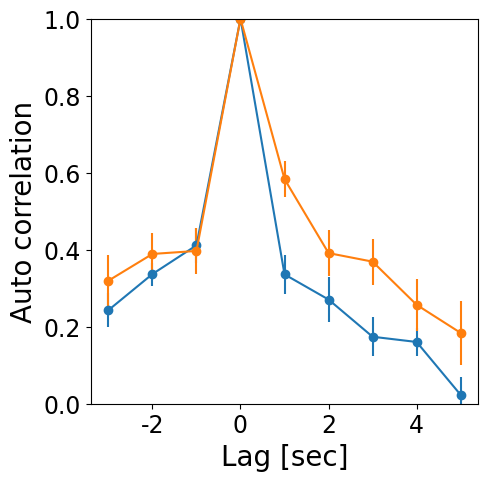

In [ ]:

frame_offset, mask_offset = 0, 0
gaze_shift_label = ['FIXA', 'PURS']
eyemovement_q = 0.9
saliency_q = 0.9
iou_q = 0.5
saliency_TR_q = 0.7
label_mode = 11.63 #1.6
use_large_cnt = True
saliency_label = 'avg_shift_norm'
modality = 'saliency_masked_image'  # 'masked_image', 'shuffled_masked_image2', 'reverse_masked_image', 'whole_image', 'saliency_masked_image'

remove_brightness = True
remove_str = ''
if remove_brightness:
    remove_str += '-remove_brightness'
if remove_empty_eyetrack:
    remove_str += '-remove_empty_eyetrack'
ret = {'sbj':[], 'hidden_layer_id': [], 'test_score_w_sal': [], 'test_score_wo_sal': [], 'delay': []}
for d_i, delay in enumerate(delay_list):
    dfs = []
    for sbj in SUBJECT_IDS:
        saliency_dir = os.path.join('../../', SAVE_ROOT, 'saliency', 'deepgaze2e_predict')
        iou_path = os.path.join('../../', SAVE_ROOT, 'mask', f'resolution{TR}-start{0}', 'iou',
                                f'sub-{sbj}.csv')

        saliency_eyetrack_path = os.path.join('../../', SAVE_ROOT, 'behavior', f'saliency_eyetrack_TR{TR}',
                                              f'{sbj}-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv')
        eye_tracking_exist_flag_dir = os.path.join('../../', SAVE_ROOT, 'features', f'pooled_{modality}-tr{TR}-fo{frame_offset}-mo{mask_offset}', sbj)
        _, w_sal_in_test, _, wo_sal_in_test = get_label(iou_path, saliency_eyetrack_path, EYEMOVE_ROOT, saliency_dir, sampling_mode, eye_tracking_exist_flag_dir,
                                                                                   saliency_label,
                                                                                    iou_q, eyemovement_q, saliency_q, sbj, gaze_shift_label, delay,
                                                                                    remove_empty_eyetrack, use_large_cnt=use_large_cnt,
                                                                                    jupyter = True,saliency_TR_q=saliency_TR_q)
        if remove_empty_eyetrack:
            ree_indices_train, ree_indices_test = get_no_empty_eyetrack_indices(eye_tracking_exist_flag_dir, delay)
            w_sal_in_test = list(set(w_sal_in_test)&set(ree_indices_test))
            wo_sal_in_test = list(set(wo_sal_in_test)&set(ree_indices_test))
        pred_and_gt_dir = os.path.join('../../', SAVE_ROOT, 'bold2feat_strict_ree2', f'delay{delay}-fo{0}-mo{0}',
                                    f'pca{pca_components}-{modality}-{sampling_mode}{remove_str}', sbj)

        pred, gt = get_pred_and_gt(pred_and_gt_dir, 0, True, slice_ = slice(4,5,1))

        for label, sal in zip([w_sal_in_test, wo_sal_in_test], ['w_sal', 'wo_sal']):
            label.sort()
            label = np.array(label)
            # gt_sal = gt[:,label,:]
            n_hidden_layers = len(pred)
            # pred, gt: num_hidden_layer x n_samples x n_components -> n_samples x (num_hidden_layer * n_components)
            for h in range(n_hidden_layers):
                if delay == 0:
                    score = correlation_score(gt[h,label,:], gt[h,label,:])
                elif delay>0:
                    src_label, tgt_label = delayed_label(label, delay)
                    score = correlation_score(gt[h,src_label,:], gt[h,tgt_label,:])
                else:
                    src_label, tgt_label = delayed_label(label, delay)
                    score = correlation_score(gt[h,src_label,:], gt[h,tgt_label,:])
                if sal == 'w_sal':
                    ret['hidden_layer_id'].append(h)
                    ret['sbj'].append(sbj)
                    ret['delay'].append(delay)
                ret['test_score'+'_'+sal].append(np.mean(score))
ret_df_rb = pd.DataFrame(ret)

fig = plt.figure(figsize=(5,5))
for sal in ['w_sal', 'wo_sal']:
    print(ret_df_rb.mean())
    print(ret_df_rb.groupby('delay').mean())
    print(ret_df_rb.query('delay ==  -1').groupby('hidden_layer_id').mean())

    print(ret_df_rb.query('delay ==  -1').mean())
    print('\n')
    means = ret_df_rb.groupby('delay').mean()
    stds = ret_df_rb.groupby('delay').std()
    if sal == 'w_sal':
        label = 'LSC'
    else:
        label = 'SSC'
    plt.errorbar(means.index, means['test_score'+'_'+sal], yerr=stds['test_score'+'_'+sal], marker='o', label=label)
# plt.legend()
plt.ylabel('Auto correlation')
plt.xlabel('Lag [sec]')
plt.ylim([0,1])
print(ret_df_rb)


# Gaze mask

../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/01-FIXA_PURS_q0.9-sal_q0.9.csv is already exist
sbj01  th2:  0.31246855875
sbj01 zero: 210
sbj01 saliency_th_upper_train:  1057.7329848865415
sbj01 saliency_th_lower_train:  424.8501357814248
label1:: gaze shift with saliency shift and small iou
	 TRAIN:: 398. TEST:: 135
label2:: gaze shift without saliency shift and small iou
	 TRAIN:: 250. TEST:: 91
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/02-FIXA_PURS_q0.9-sal_q0.9.csv is already exist
sbj02  th2:  0.31246855875
sbj02 zero: 28
sbj02 saliency_th_upper_train:  1057.7329848865415
sbj02 saliency_th_lower_train:  424.8501357814248
label1:: gaze shift with saliency shift and small iou
	 TRAIN:: 463. TEST:: 149
label2:: gaze shift without saliency shift and small iou
	 TRAIN:: 321. TEST:: 104
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/03-FIXA_PURS_q0.9-sal_q0.9.csv is already exist
sbj03  th2:  0.31246855875
sbj03 z

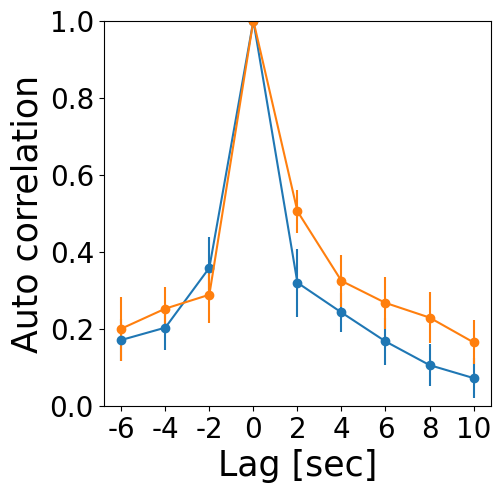

In [ ]:

frame_offset, mask_offset = 0, 0
gaze_shift_label = ['FIXA', 'PURS']
eyemovement_q = 0.9
saliency_q = 0.9
saliency_TR_q = 0.7
iou_q = 0.5
use_large_cnt = True
saliency_label = 'avg_shift_norm'
modality = 'masked_image'

remove_brightness = True
remove_str = ''
if remove_brightness:
    remove_str += '-remove_brightness'
if remove_empty_eyetrack:
    remove_str += '-remove_empty_eyetrack'
ret = {'sbj':[], 'hidden_layer_id': [], 'test_score_w_sal': [], 'test_score_wo_sal': [], 'delay': []}
for d_i, delay in enumerate(delay_list):
    dfs = []
    for sbj in SUBJECT_IDS:
        saliency_dir = os.path.join('../../', SAVE_ROOT, 'saliency', 'deepgaze2e_predict')
        iou_path = os.path.join('../../', SAVE_ROOT, 'mask', f'resolution{TR}-start{0}', 'iou',
                                f'sub-{sbj}.csv')

        saliency_eyetrack_path = os.path.join('../../', SAVE_ROOT, 'behavior', f'saliency_eyetrack_TR{TR}',
                                              f'{sbj}-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv')
        eye_tracking_exist_flag_dir = os.path.join('../../', SAVE_ROOT, 'features', f'pooled_{modality}-tr{TR}-fo{frame_offset}-mo{mask_offset}', sbj)
        _, w_sal_in_test, _, wo_sal_in_test = get_label(iou_path, saliency_eyetrack_path, EYEMOVE_ROOT, saliency_dir, sampling_mode, eye_tracking_exist_flag_dir,
                                                                                   saliency_label,
                                                                                    iou_q, eyemovement_q, saliency_q, sbj, gaze_shift_label, delay,
                                                                                    remove_empty_eyetrack, use_large_cnt=use_large_cnt,
                                                                                    jupyter = True,saliency_TR_q=saliency_TR_q)
        if remove_empty_eyetrack:
            ree_indices_train, ree_indices_test = get_no_empty_eyetrack_indices(eye_tracking_exist_flag_dir, delay)
            w_sal_in_test = list(set(w_sal_in_test)&set(ree_indices_test))
            wo_sal_in_test = list(set(wo_sal_in_test)&set(ree_indices_test))
        pred_and_gt_dir = os.path.join('../../', SAVE_ROOT, 'bold2feat_strict_ree2', f'delay{delay}-fo{0}-mo{0}',
                                    f'pca{pca_components}-{modality}-{sampling_mode}{remove_str}', sbj)

        pred, gt = get_pred_and_gt(pred_and_gt_dir, 0, True, slice_ = slice(4,5,1))

        for label, sal in zip([w_sal_in_test, wo_sal_in_test], ['w_sal', 'wo_sal']):
            label.sort()
            label = np.array(label)
            # gt_sal = gt[:,label,:]
            n_hidden_layers = len(pred)
            # pred, gt: num_hidden_layer x n_samples x n_components -> n_samples x (num_hidden_layer * n_components)
            for h in range(n_hidden_layers):
                if delay == 0:
                    score = correlation_score(gt[h,label,:], gt[h,label,:])
                elif delay>0:
                    src_label, tgt_label = delayed_label(label, delay)
                    score = correlation_score(gt[h,src_label,:], gt[h,tgt_label,:])
                else:
                    src_label, tgt_label = delayed_label(label, delay)
                    score = correlation_score(gt[h,src_label,:], gt[h,tgt_label,:])
                if sal == 'w_sal':
                    ret['hidden_layer_id'].append(h)
                    ret['sbj'].append(sbj)
                    ret['delay'].append(delay)
                ret['test_score'+'_'+sal].append(np.mean(score))
ret_df_rb = pd.DataFrame(ret)

fig = plt.figure(figsize=(5,5))
for sal in ['w_sal', 'wo_sal']:
    print(ret_df_rb.mean())
    print(ret_df_rb.groupby('delay').mean())
    print(ret_df_rb.query('delay ==  -1').groupby('hidden_layer_id').mean())

    print(ret_df_rb.query('delay ==  -1').mean())
    print('\n')
    means = ret_df_rb.groupby('delay').mean()
    stds = ret_df_rb.groupby('delay').std()
    if sal == 'w_sal':
        label = 'LSC'
    else:
        label = 'SSC'
    plt.errorbar(means.index, means['test_score'+'_'+sal], yerr=stds['test_score'+'_'+sal], marker='o', label=label)
# plt.legend()
plt.ylabel('Auto correlation')
plt.xlabel('Lag [sec]')
plt.xticks(delay_list, [str(2*d) for d in delay_list])
plt.ylim([0,1])
# plt.title(f'iou threshold: {iou_q}')
# plt.show()
savepath = os.path.join('figures', 'sup_fig2', f'AutoCorrelation_of_{modality}_wo_legend.pdf')
os.makedirs(os.path.dirname(savepath), exist_ok=True); plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)
print(ret_df_rb)


# Saliency Mask

../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/01-FIXA_PURS_q0.9-sal_q0.9.csv is already exist
sbj01  th2:  0.31246855875
sbj01 zero: 210
sbj01 saliency_th_upper_train:  1057.7329848865415
sbj01 saliency_th_lower_train:  424.8501357814248
label1:: gaze shift with saliency shift and small iou
	 TRAIN:: 398. TEST:: 135
label2:: gaze shift without saliency shift and small iou
	 TRAIN:: 250. TEST:: 91
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/02-FIXA_PURS_q0.9-sal_q0.9.csv is already exist
sbj02  th2:  0.31246855875
sbj02 zero: 28
sbj02 saliency_th_upper_train:  1057.7329848865415
sbj02 saliency_th_lower_train:  424.8501357814248
label1:: gaze shift with saliency shift and small iou
	 TRAIN:: 463. TEST:: 149
label2:: gaze shift without saliency shift and small iou
	 TRAIN:: 321. TEST:: 104
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/03-FIXA_PURS_q0.9-sal_q0.9.csv is already exist
sbj03  th2:  0.31246855875
sbj03 z

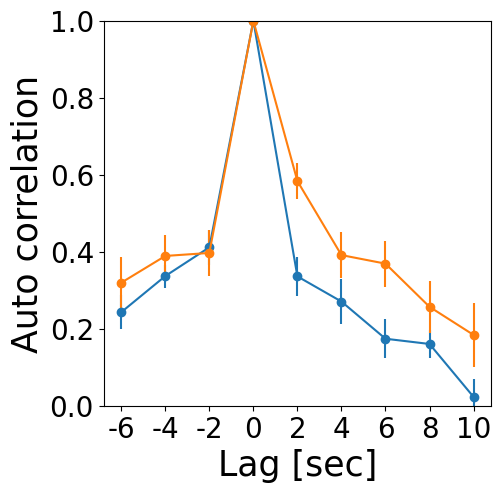

In [ ]:


frame_offset, mask_offset = 0, 0
gaze_shift_label = ['FIXA', 'PURS']
eyemovement_q = 0.9
saliency_q = 0.9
saliency_TR_q = 0.7
iou_q = 0.5
use_large_cnt = True
saliency_label = 'avg_shift_norm'
modality = 'saliency_masked_image'

remove_brightness = True
remove_str = ''
if remove_brightness:
    remove_str += '-remove_brightness'
if remove_empty_eyetrack:
    remove_str += '-remove_empty_eyetrack'
ret = {'sbj':[], 'hidden_layer_id': [], 'test_score_w_sal': [], 'test_score_wo_sal': [], 'delay': []}
for d_i, delay in enumerate(delay_list):
    dfs = []
    for sbj in SUBJECT_IDS:
        saliency_dir = os.path.join('../../', SAVE_ROOT, 'saliency', 'deepgaze2e_predict')
        iou_path = os.path.join('../../', SAVE_ROOT, 'mask', f'resolution{TR}-start{0}', 'iou',
                                f'sub-{sbj}.csv')

        saliency_eyetrack_path = os.path.join('../../', SAVE_ROOT, 'behavior', f'saliency_eyetrack_TR{TR}',
                                              f'{sbj}-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv')
        eye_tracking_exist_flag_dir = os.path.join('../../', SAVE_ROOT, 'features', f'pooled_{modality}-tr{TR}-fo{frame_offset}-mo{mask_offset}', sbj)
        _, w_sal_in_test, _, wo_sal_in_test = get_label(iou_path, saliency_eyetrack_path, EYEMOVE_ROOT, saliency_dir, sampling_mode, eye_tracking_exist_flag_dir,
                                                                                   saliency_label,
                                                                                    iou_q, eyemovement_q, saliency_q, sbj, gaze_shift_label, delay,
                                                                                    remove_empty_eyetrack, use_large_cnt=use_large_cnt,
                                                                                    jupyter = True,saliency_TR_q=saliency_TR_q)
        if remove_empty_eyetrack:
            ree_indices_train, ree_indices_test = get_no_empty_eyetrack_indices(eye_tracking_exist_flag_dir, delay)
            w_sal_in_test = list(set(w_sal_in_test)&set(ree_indices_test))
            wo_sal_in_test = list(set(wo_sal_in_test)&set(ree_indices_test))
        pred_and_gt_dir = os.path.join('../../', SAVE_ROOT, 'bold2feat_strict_ree2', f'delay{delay}-fo{0}-mo{0}',
                                    f'pca{pca_components}-{modality}-{sampling_mode}{remove_str}', sbj)

        pred, gt = get_pred_and_gt(pred_and_gt_dir, 0, True, slice_ = slice(4,5,1))

        for label, sal in zip([w_sal_in_test, wo_sal_in_test], ['w_sal', 'wo_sal']):
            label.sort()
            label = np.array(label)
            # gt_sal = gt[:,label,:]
            n_hidden_layers = len(pred)
            # pred, gt: num_hidden_layer x n_samples x n_components -> n_samples x (num_hidden_layer * n_components)
            for h in range(n_hidden_layers):
                if delay == 0:
                    score = correlation_score(gt[h,label,:], gt[h,label,:])
                elif delay>0:
                    src_label, tgt_label = delayed_label(label, delay)
                    score = correlation_score(gt[h,src_label,:], gt[h,tgt_label,:])
                else:
                    src_label, tgt_label = delayed_label(label, delay)
                    score = correlation_score(gt[h,src_label,:], gt[h,tgt_label,:])
                if sal == 'w_sal':
                    ret['hidden_layer_id'].append(h)
                    ret['sbj'].append(sbj)
                    ret['delay'].append(delay)
                ret['test_score'+'_'+sal].append(np.mean(score))
ret_df_rb = pd.DataFrame(ret)

fig = plt.figure(figsize=(5,5))
for sal in ['w_sal', 'wo_sal']:
    print(ret_df_rb.mean())
    print(ret_df_rb.groupby('delay').mean())
    print(ret_df_rb.query('delay ==  -1').groupby('hidden_layer_id').mean())

    print(ret_df_rb.query('delay ==  -1').mean())
    print('\n')
    means = ret_df_rb.groupby('delay').mean()
    stds = ret_df_rb.groupby('delay').std()
    if sal == 'w_sal':
        label = 'LSC'
    else:
        label = 'SSC'
    plt.errorbar(means.index, means['test_score'+'_'+sal], yerr=stds['test_score'+'_'+sal], marker='o', label=label)
# plt.legend()
plt.ylabel('Auto correlation')
plt.xlabel('Lag [sec]')
plt.xticks(delay_list, [str(2*d) for d in delay_list])
plt.ylim([0,1])
print(ret_df_rb)


# Shuffled Mask

../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/01-FIXA_PURS_q0.9-sal_q0.9.csv is already exist
sbj01  th2:  0.31246855875
sbj01 zero: 210
sbj01 saliency_th_upper_train:  1057.7329848865415
sbj01 saliency_th_lower_train:  424.8501357814248
label1:: gaze shift with saliency shift and small iou
	 TRAIN:: 398. TEST:: 135
label2:: gaze shift without saliency shift and small iou
	 TRAIN:: 250. TEST:: 91
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/02-FIXA_PURS_q0.9-sal_q0.9.csv is already exist
sbj02  th2:  0.31246855875
sbj02 zero: 28
sbj02 saliency_th_upper_train:  1057.7329848865415
sbj02 saliency_th_lower_train:  424.8501357814248
label1:: gaze shift with saliency shift and small iou
	 TRAIN:: 463. TEST:: 149
label2:: gaze shift without saliency shift and small iou
	 TRAIN:: 321. TEST:: 104
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/03-FIXA_PURS_q0.9-sal_q0.9.csv is already exist
sbj03  th2:  0.31246855875
sbj03 z

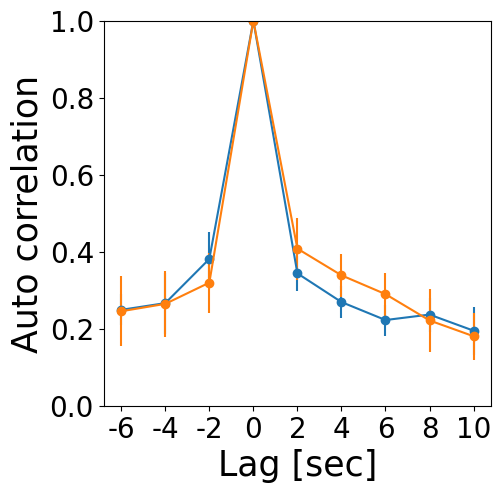

In [ ]:


frame_offset, mask_offset = 0, 0
gaze_shift_label = ['FIXA', 'PURS']
eyemovement_q = 0.9
saliency_q = 0.9
saliency_TR_q = 0.7
iou_q = 0.5
use_large_cnt = True
saliency_label = 'avg_shift_norm'
modality = 'shuffled_masked_image2'

remove_brightness = True
remove_str = ''
if remove_brightness:
    remove_str += '-remove_brightness'
if remove_empty_eyetrack:
    remove_str += '-remove_empty_eyetrack'
ret = {'sbj':[], 'hidden_layer_id': [], 'test_score_w_sal': [], 'test_score_wo_sal': [], 'delay': []}
for d_i, delay in enumerate(delay_list):
    dfs = []
    for sbj in SUBJECT_IDS:
        saliency_dir = os.path.join('../../', SAVE_ROOT, 'saliency', 'deepgaze2e_predict')
        iou_path = os.path.join('../../', SAVE_ROOT, 'mask', f'resolution{TR}-start{0}', 'iou',
                                f'sub-{sbj}.csv')

        saliency_eyetrack_path = os.path.join('../../', SAVE_ROOT, 'behavior', f'saliency_eyetrack_TR{TR}',
                                              f'{sbj}-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv')
        eye_tracking_exist_flag_dir = os.path.join('../../', SAVE_ROOT, 'features', f'pooled_{modality}-tr{TR}-fo{frame_offset}-mo{mask_offset}', sbj)
        _, w_sal_in_test, _, wo_sal_in_test = get_label(iou_path, saliency_eyetrack_path, EYEMOVE_ROOT, saliency_dir, sampling_mode, eye_tracking_exist_flag_dir,
                                                                                   saliency_label,
                                                                                    iou_q, eyemovement_q, saliency_q, sbj, gaze_shift_label, delay,
                                                                                    remove_empty_eyetrack, use_large_cnt=use_large_cnt,
                                                                                    jupyter = True,saliency_TR_q=saliency_TR_q)
        if remove_empty_eyetrack:
            ree_indices_train, ree_indices_test = get_no_empty_eyetrack_indices(eye_tracking_exist_flag_dir, delay)
            w_sal_in_test = list(set(w_sal_in_test)&set(ree_indices_test))
            wo_sal_in_test = list(set(wo_sal_in_test)&set(ree_indices_test))
        pred_and_gt_dir = os.path.join('../../', SAVE_ROOT, 'bold2feat_strict_ree2', f'delay{delay}-fo{0}-mo{0}',
                                    f'pca{pca_components}-{modality}-{sampling_mode}{remove_str}', sbj)

        pred, gt = get_pred_and_gt(pred_and_gt_dir, 0, True, slice_ = slice(4,5,1))

        for label, sal in zip([w_sal_in_test, wo_sal_in_test], ['w_sal', 'wo_sal']):
            label.sort()
            label = np.array(label)
            # gt_sal = gt[:,label,:]
            n_hidden_layers = len(pred)
            # pred, gt: num_hidden_layer x n_samples x n_components -> n_samples x (num_hidden_layer * n_components)
            for h in range(n_hidden_layers):
                if delay == 0:
                    score = correlation_score(gt[h,label,:], gt[h,label,:])
                elif delay>0:
                    src_label, tgt_label = delayed_label(label, delay)
                    score = correlation_score(gt[h,src_label,:], gt[h,tgt_label,:])
                else:
                    src_label, tgt_label = delayed_label(label, delay)
                    score = correlation_score(gt[h,src_label,:], gt[h,tgt_label,:])
                if sal == 'w_sal':
                    ret['hidden_layer_id'].append(h)
                    ret['sbj'].append(sbj)
                    ret['delay'].append(delay)
                ret['test_score'+'_'+sal].append(np.mean(score))
ret_df_rb = pd.DataFrame(ret)

fig = plt.figure(figsize=(5,5))
for sal in ['w_sal', 'wo_sal']:
    print(ret_df_rb.mean())
    print(ret_df_rb.groupby('delay').mean())
    print(ret_df_rb.query('delay ==  -1').groupby('hidden_layer_id').mean())

    print(ret_df_rb.query('delay ==  -1').mean())
    print('\n')
    means = ret_df_rb.groupby('delay').mean()
    stds = ret_df_rb.groupby('delay').std()
    if sal == 'w_sal':
        label = 'LSC'
    else:
        label = 'SSC'
    plt.errorbar(means.index, means['test_score'+'_'+sal], yerr=stds['test_score'+'_'+sal], marker='o', label=label)
# plt.legend()
plt.ylabel('Auto correlation')
plt.xlabel('Lag [sec]')
plt.xticks(delay_list, [str(2*d) for d in delay_list])
plt.ylim([0,1])
print(ret_df_rb)
